In [10]:
from svd_utils import *
from sklearn.cluster import KMeans
import sys
sys.path.append("../")  # Goes up to "project/"
import numpy as np
import matplotlib.pyplot as plt

TODO
* Do a grid with the lattice blocks for the heatmap, that way I can tell is all the elements in one block are zero, which shouldn't be the case.

In [2]:
#Restrict test vectors to a particular block and apply SVD
Nx, Nt, block_x, block_t = 64,64,8,8
x_elements, t_elements = Nx//block_x,Nt//block_t
blockID = 0
bx = blockID // block_x
bt = blockID % block_t 
#----Coordinates of elements inside block----#
xini, tini = x_elements * bx, t_elements * bt
xfin = xini + x_elements
tfin = tini + t_elements
print("Restricting to block {0}".format(blockID))
print("t in range {0} - {1}".format(tini,tfin))
print("x in range {0} - {1}".format(xini,xfin))
print("------------------------")

#[2, "m-018", "-01884",0.008], [4, "m-01023","-01023",0.001], [6, "m-0709","-00709",0.001] [beta, m0_folder, m0_str]
beta, m0_folder ,m0_str, m0_diff = 4, "m-01023","-01023",0.001
nconf = 0
NV = 30
k_rank = 5
SAP_block_size = 16
print("beta={0}, conf={1}, Nv={2}, Nx={3}, Nt={4}\nblocks_x={5}, blocks_t={6}, bx_size={7}, bt_size={8}".format
         (beta,nconf,NV,Nx,Nt,block_x,block_t,Nx//block_x,Nt//block_t)
         )

Restricting to block 0
t in range 0 - 8
x in range 0 - 8
------------------------
beta=4, conf=0, Nv=30, Nx=64, Nt=64
blocks_x=8, blocks_t=8, bx_size=8, bt_size=8


# SVD 1
* Restrict test vectors to a lattice block and apply SVD

We restrict the test vectors to a lattice block (we ignore the rest of the components by creating a new vector which only has the components inside the block) and apply the SVD those restricted vectors, for a certain spin.

In [3]:
params_list = [beta, m0_str, m0_folder, nconf, NV, Nx, Nt]
dtv_spin0, dtv_spin1 = read_and_decompose(blockID,block_x,block_t,params_list)
print("\nSpin component 0")
low_rank_tv0 = apply_SVD(dtv_spin0,k_rank)
low_rank_tv0 = low_rank_tv0.reshape(t_elements,x_elements,NV);
print("Low rank test vectors shape after reshaping",low_rank_tv0.shape)
print("\nSpin component 1")
low_rank_tv1 = apply_SVD(dtv_spin1,k_rank)
low_rank_tv1 =low_rank_tv1.reshape(t_elements,x_elements,NV);
print("Low rank test vectors shape after reshaping",low_rank_tv1.shape)


Spin component 0
matrix succesfully reconstructed
-------------------
Uk shape (64, 5)
sk shape (5,)
Vk shape (5, 30)
Low rank test vectors shape (64, 30)
Low rank test vectors shape after reshaping (8, 8, 30)

Spin component 1
matrix succesfully reconstructed
-------------------
Uk shape (64, 5)
sk shape (5,)
Vk shape (5, 30)
Low rank test vectors shape (64, 30)
Low rank test vectors shape after reshaping (8, 8, 30)


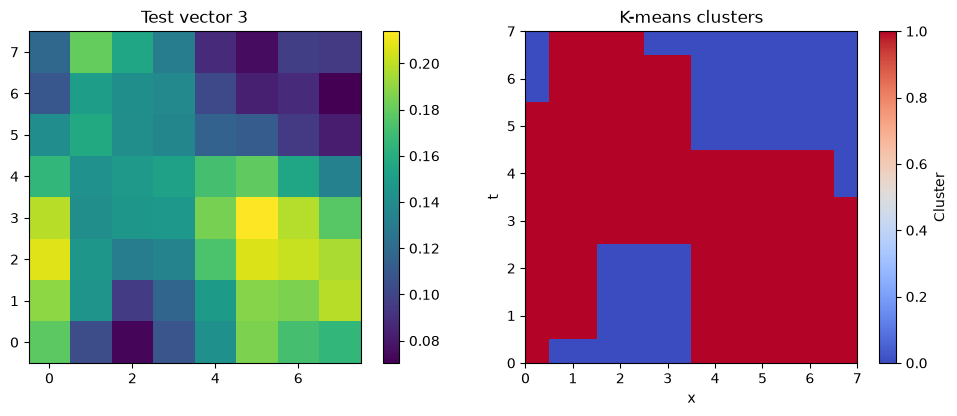

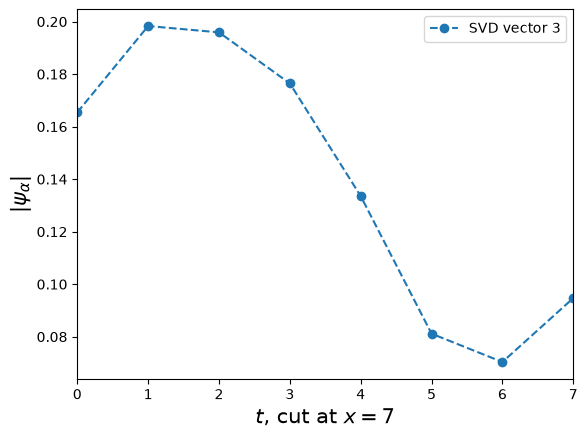

In [9]:
tvID = 3
xlims = [0,x_elements-1]
tlims = [0,t_elements-1]
make_heatmap_and_k_cluster(low_rank_tv1,xlims,tlims,tvID)
#Plot of a cut
cut = 7
X = np.arange(0,low_rank_tv1.shape[0])
plt.plot(X,np.abs(low_rank_tv1[:,cut,tvID]),marker='o',linestyle='--',label='SVD vector {0}'.format(tvID))
plt.legend()
plt.ylabel(r"$|\psi_\alpha|$",size=15)
plt.xlabel(r"$t$, cut at $x=${0}".format(cut),size=15)
plt.xlim(tlims)
plt.show()

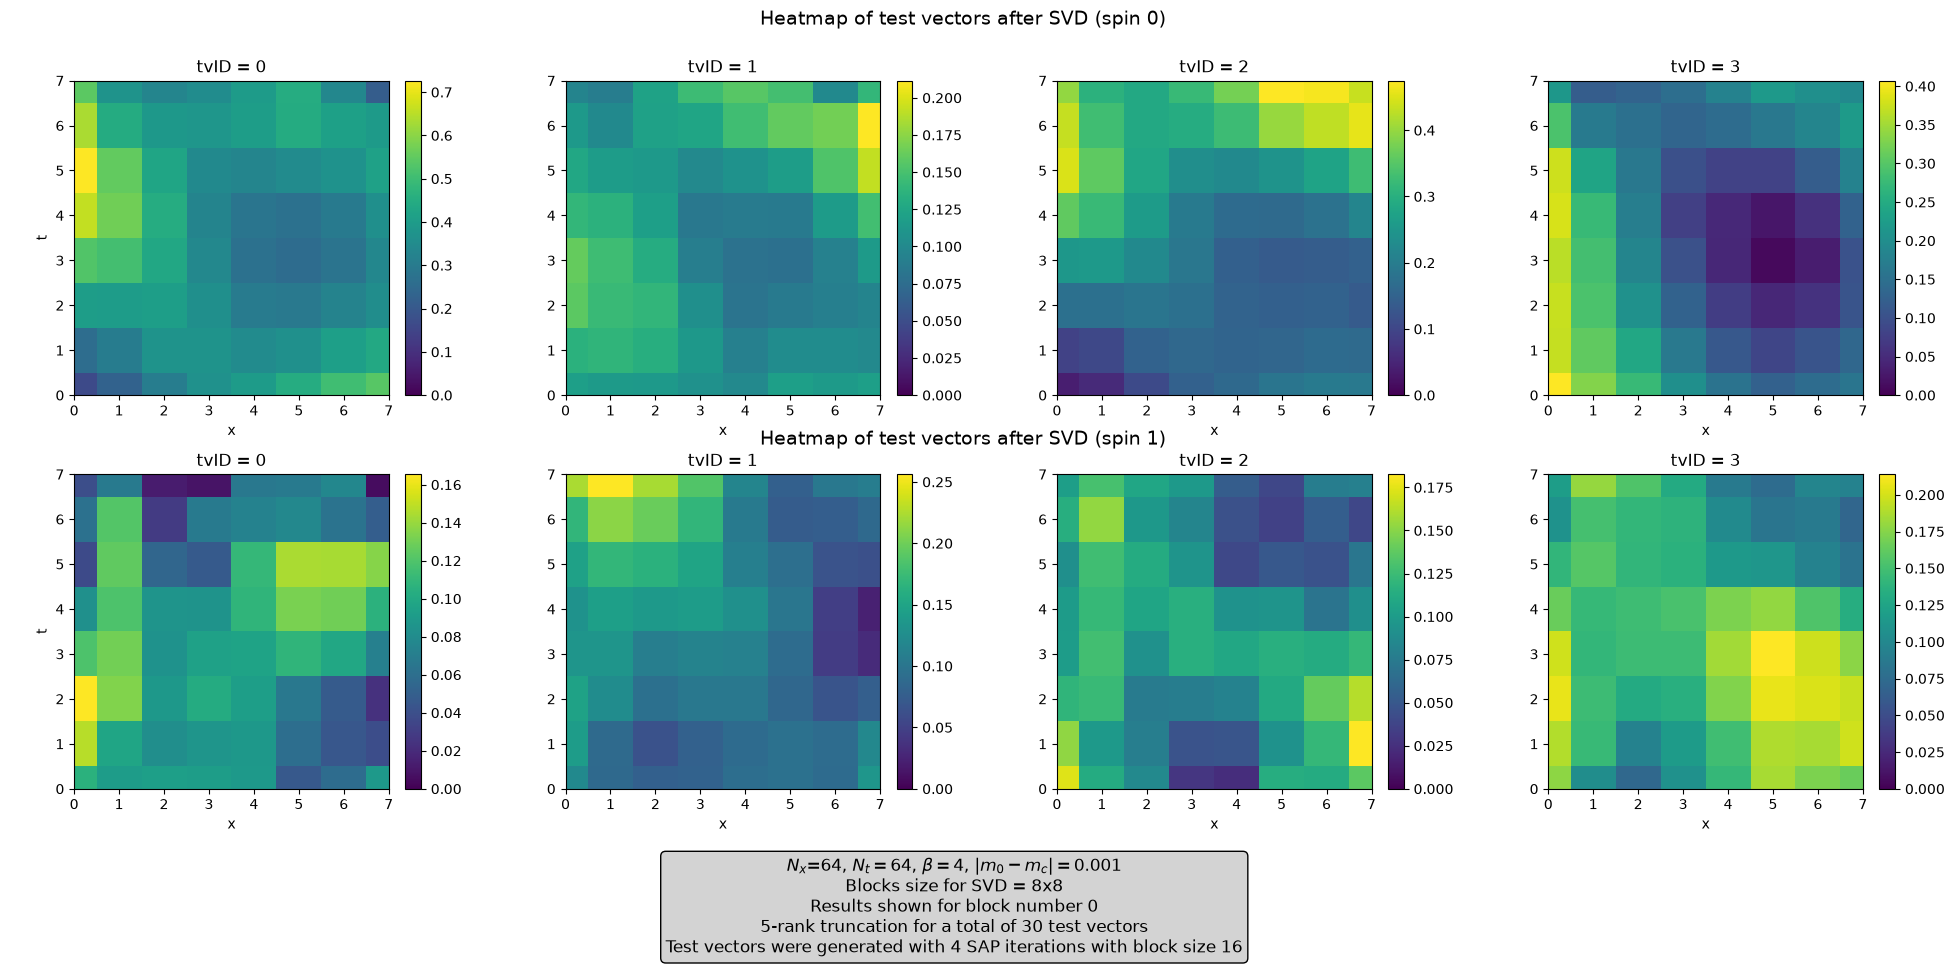

In [5]:
fig_name = "heatmaps_blockID{0}_bsize{1}_beta{2}.pdf".format(blockID,x_elements,beta)
metadata = [Nx, Nt, beta, m0_diff, x_elements,blockID, k_rank, NV,SAP_block_size]
save=False
make_heatmaps(low_rank_tv0, low_rank_tv1,xlims,tlims,metadata,fig_name,save)

In [6]:
for confID in range(10):
    params_list = [beta, m0_str, m0_folder, nconf, NV, Nx, Nt]
    masked_test_vectors = mask_vectors(k_rank,block_x,block_t,params_list)
    save_vectors(masked_test_vectors,beta,Nx,Nt,m0_folder,confID,k_rank)
print(masked_test_vectors.shape)

(30, 2, 64, 64)


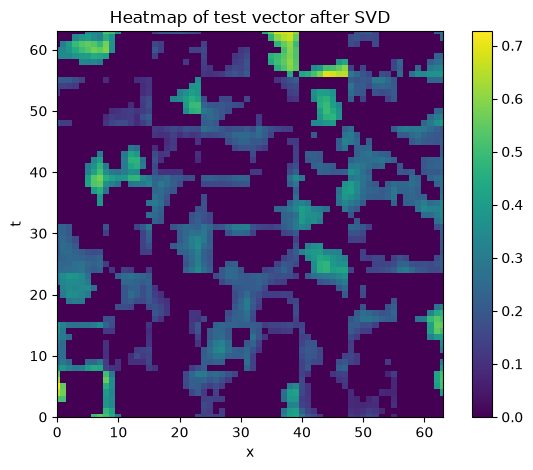


Spin component 0
matrix succesfully reconstructed
-------------------
Uk shape (64, 5)
sk shape (5,)
Vk shape (5, 30)
Low rank test vectors shape (64, 30)


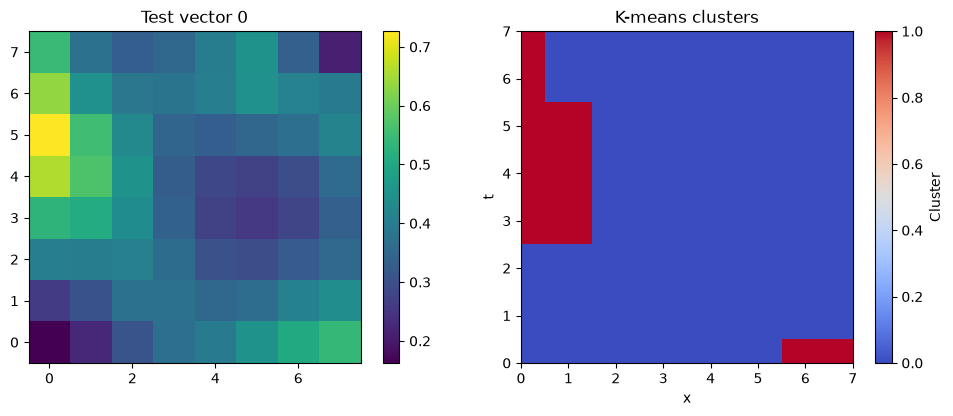

In [11]:
tvID = 0

fig, ax = plt.subplots()
im = ax.imshow(np.abs((masked_test_vectors[tvID,0,:,:])))
ax.set_xlabel(r"x")
ax.set_ylabel(r"t")
ax.set_xlim([0,63])
ax.set_ylim([0,63])
ax.set_title("Heatmap of test vector after SVD")
ax.figure.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

blockID = 0
params_list = [beta, m0_str, m0_folder, nconf, NV, Nx, Nt]
dtv_spin0, dtv_spin1 = read_and_decompose(blockID,block_x,block_t,params_list)
print("\nSpin component 0")
low_rank_tv0 = apply_SVD(dtv_spin0,k_rank)
low_rank_tv0 = low_rank_tv0.reshape(t_elements,x_elements,NV);

xlims = [0,x_elements-1]
tlims = [0,t_elements-1]
make_heatmap_and_k_cluster(low_rank_tv0,xlims,tlims,tvID)